Objetivo

Determinar si la fuerte correlación observada entre Price_Y y Price_Equipo1
(r = 0.997) corresponde a una relación estadística genuina o a una
correlación espuria derivada de la no estacionariedad de las series.

Objetivo:

- Evaluar si las series parecen moverse juntas en el largo plazo.
- Identificar divergencias o convergencias visuales.
- Detectar posibles cambios estructurales.
- Obtener evidencia preliminar antes de aplicar pruebas estadísticas.

In [29]:
# =====================================================
# 0. LIBRERÍAS Y RUTAS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas del proyecto (funciona con cwd = repo root o notebooks/)
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / 'data' / 'processed').exists() else _cwd.parent
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH = PROJECT_ROOT / 'reports'

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 6)

print('Librerías cargadas correctamente.')
print(f'  PROJECT_ROOT : {PROJECT_ROOT}')

Librerías cargadas correctamente.
  PROJECT_ROOT : c:\Users\Maria Jose\Desktop\dataknow-costos-operativos


In [30]:
# =====================================================
# 0.1 CARGA DEL DATASET PROCESADO
# =====================================================

df = pd.read_csv(PROCESSED_PATH / 'historico_equipos_limpio.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('Dataset procesado cargado correctamente')
print(f'  Filas    : {df.shape[0]:,}')
print(f'  Columnas : {df.shape[1]}')
print(f'  Periodo  : {df["Date"].min().date()} → {df["Date"].max().date()}')

df.head()

Dataset procesado cargado correctamente
  Filas    : 3,530
  Columnas : 6
  Periodo  : 2010-01-04 → 2023-08-31


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


In [31]:
# =====================================================
# 1.1 PREPARACIÓN DE DATOS
# =====================================================

# Copia de trabajo
df_plot = df.copy()

# Fecha como índice
df_plot['Date'] = pd.to_datetime(df_plot['Date'])
df_plot = df_plot.set_index('Date')

print('Periodo:')
print(df_plot.index.min(), '->', df_plot.index.max())

print('\nObservaciones:')
print(len(df_plot))

Periodo:
2010-01-04 00:00:00 -> 2023-08-31 00:00:00

Observaciones:
3530


### 1.2 Evolución temporal en valores originales

Antes de indexar a Base 100, revisamos los **pares bajo auditoría** en su escala natural.

**¿Por qué incluir este paso?**
- El índice Base 100 facilita comparar *cambios relativos*, pero oculta las **magnitudes absolutas** (p. ej. Price_Z ~2.000 vs Price_Equipo2 ~900).
- En un diagnóstico de correlación espuria conviene ver si la similitud visual en niveles se debe a **tendencias comunes** o a una relación estable en unidades reales.
- No repetimos el EDA completo del notebook 01: aquí solo los pares Y↔Equipo1 y Z↔Equipo2.

**Lectura esperada:** si las series suben y bajan juntas *incluso en escala original*, hay indicios preliminares de co-movimiento; la prueba definitiva vendrá con estacionariedad y co-integración.

,Par,Min MP,Max MP,Min Eq,Max Eq,Corr (niveles)
0,Y ↔ Equipo1,257.5,1062.37,208.34,855.32,0.9966
1,Z ↔ Equipo2,1421.5,3984.00,566.00,1703.96,0.9827


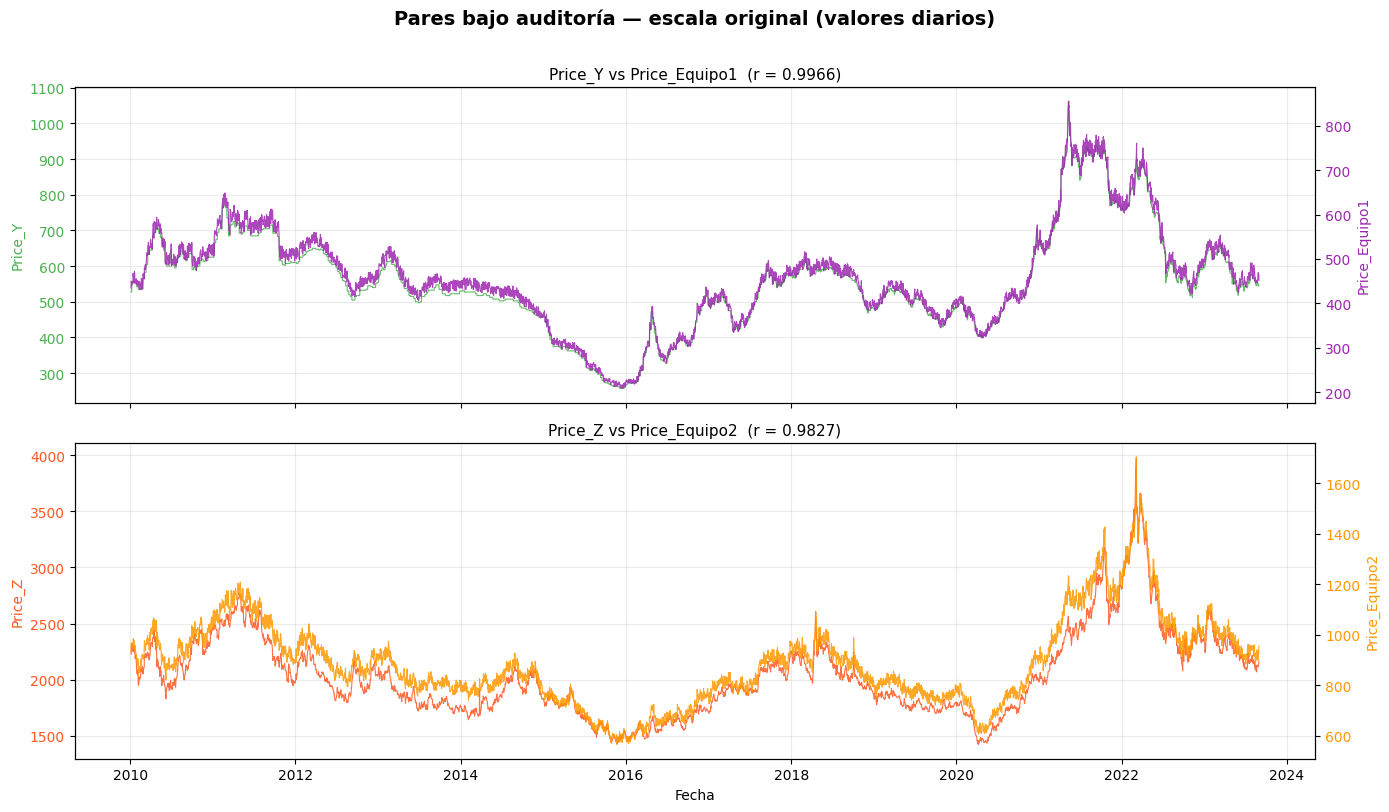

In [32]:
# =====================================================
# 1.2 EVOLUCIÓN TEMPORAL — VALORES ORIGINALES
# =====================================================

PARES = [
    ('Price_Y', 'Price_Equipo1', 'Price_Y', 'Price_Equipo1', '#4CAF50', '#9C27B0'),
    ('Price_Z', 'Price_Equipo2', 'Price_Z', 'Price_Equipo2', '#FF5722', '#FF9800'),
]

# Contexto de magnitud
filas_mag = []
for col_mp, col_eq, *_ in PARES:
    filas_mag.append({
        'Par': f'{col_mp.replace("Price_", "")} ↔ {col_eq.replace("Price_", "")}',
        'Min MP': df_plot[col_mp].min(),
        'Max MP': df_plot[col_mp].max(),
        'Min Eq': df_plot[col_eq].min(),
        'Max Eq': df_plot[col_eq].max(),
        'Corr (niveles)': df_plot[col_mp].corr(df_plot[col_eq]),
    })
display(pd.DataFrame(filas_mag).round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Pares bajo auditoría — escala original (valores diarios)',
    fontsize=14, fontweight='bold', y=1.01,
)

for ax, (col_mp, col_eq, lbl_mp, lbl_eq, c_mp, c_eq) in zip(axes, PARES):
    ax.plot(df_plot.index, df_plot[col_mp], color=c_mp, linewidth=0.8, alpha=0.85, label=lbl_mp)
    ax.set_ylabel(lbl_mp, color=c_mp)
    ax.tick_params(axis='y', labelcolor=c_mp)

    ax2 = ax.twinx()
    ax2.plot(df_plot.index, df_plot[col_eq], color=c_eq, linewidth=0.8, alpha=0.85, label=lbl_eq)
    ax2.set_ylabel(lbl_eq, color=c_eq)
    ax2.tick_params(axis='y', labelcolor=c_eq)

    r = df_plot[col_mp].corr(df_plot[col_eq])
    ax.set_title(f'{lbl_mp} vs {lbl_eq}  (r = {r:.4f})', fontsize=11)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_diagnostico_niveles_originales.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
# =====================================================
# FUNCIÓN DE INDEXACIÓN BASE 100
# =====================================================

def base100(series):
    return (series / series.iloc[0]) * 100

In [34]:
# =====================================================
# SERIES INDEXADAS BASE 100 — pares de auditoría
# =====================================================

series_base100 = pd.DataFrame(index=df_plot.index)
series_base100['Y'] = base100(df_plot['Price_Y'])
series_base100['Equipo1'] = base100(df_plot['Price_Equipo1'])
series_base100['Z'] = base100(df_plot['Price_Z'])
series_base100['Equipo2'] = base100(df_plot['Price_Equipo2'])

MAPA_BASE100 = {
    'Price_Y': 'Y',
    'Price_Equipo1': 'Equipo1',
    'Price_Z': 'Z',
    'Price_Equipo2': 'Equipo2',
}

print(series_base100.shape)
series_base100.head()

(3530, 4)


,Y,Equipo1,Z,Equipo2
Date,,,,
2010-01-04,100.000000,100.000000,100.000000,100.000000
2010-01-05,100.000000,103.505624,100.954949,103.952862
2010-01-06,100.000000,102.242771,103.471520,103.088878
2010-01-07,100.000000,101.419272,103.651275,103.049167
2010-01-08,104.739336,103.241092,101.617796,101.912571


### 1.3 Evolución relativa — Base 100

Misma estructura que la sección 1.2: **Price_Y vs Price_Equipo1** arriba y **Price_Z vs Price_Equipo2** abajo, indexados a 100 desde el primer día del período.

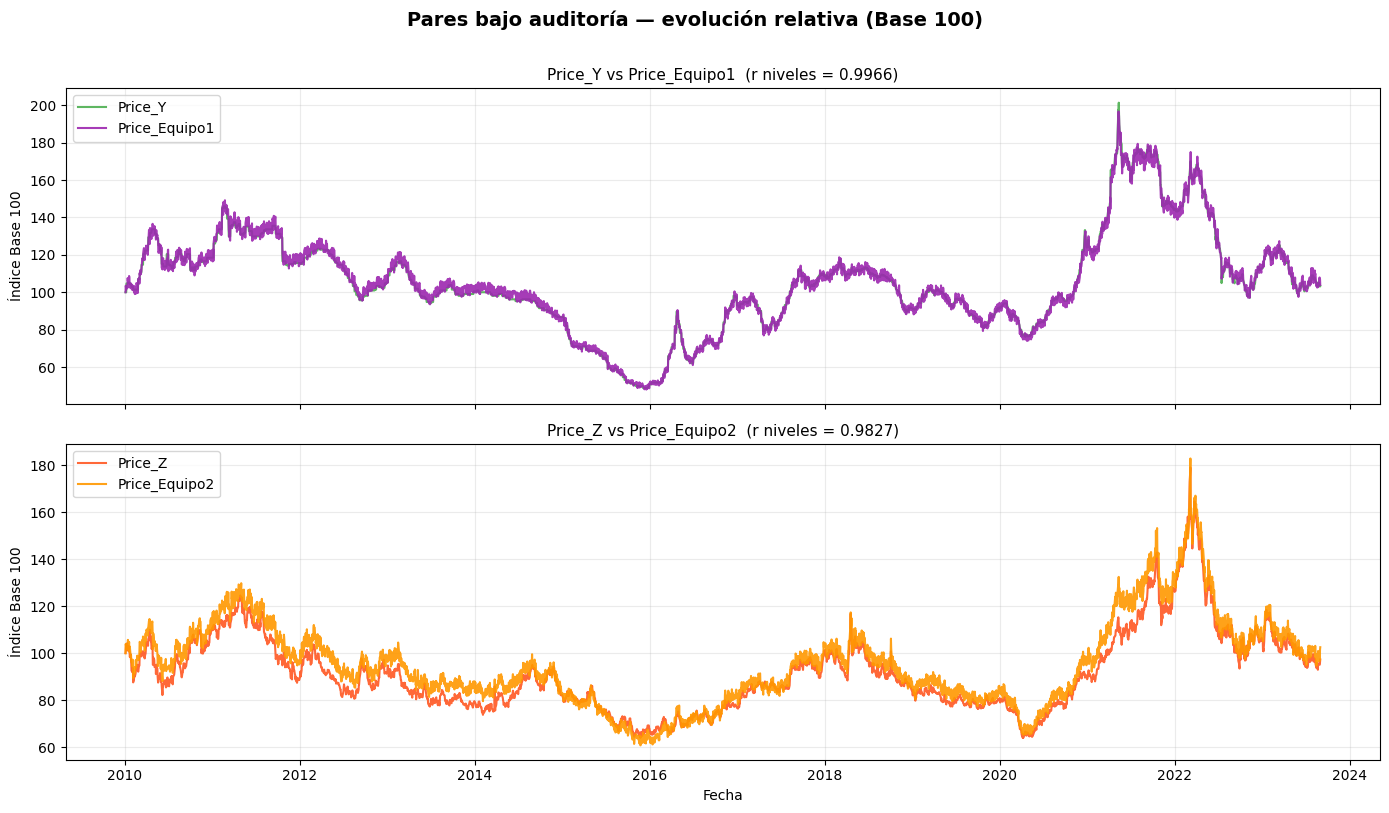

In [35]:
# =====================================================
# 1.3 EVOLUCIÓN RELATIVA — BASE 100 (ambos pares)
# =====================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Pares bajo auditoría — evolución relativa (Base 100)',
    fontsize=14, fontweight='bold', y=1.01,
)

for ax, (col_mp, col_eq, lbl_mp, lbl_eq, c_mp, c_eq) in zip(axes, PARES):
    ax.plot(
        series_base100.index,
        series_base100[MAPA_BASE100[col_mp]],
        linewidth=1.5, color=c_mp, alpha=0.9, label=lbl_mp,
    )
    ax.plot(
        series_base100.index,
        series_base100[MAPA_BASE100[col_eq]],
        linewidth=1.5, color=c_eq, alpha=0.9, label=lbl_eq,
    )
    r = df_plot[col_mp].corr(df_plot[col_eq])
    ax.set_title(f'{lbl_mp} vs {lbl_eq}  (r niveles = {r:.4f})', fontsize=11)
    ax.set_ylabel('Índice Base 100')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_diagnostico_base100_pares.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.4 Panel comparativo — Scatter clásico · Scatter temporal · Trayectoria\n
\n
Tres vistas en un solo panel **2 × 3** (una fila por par de auditoría):\n
\n
| Columna | Qué muestra |\n
|---------|-------------|\n
| **Scatter clásico** | Relación en plano Base 100 + tendencia lineal |\n
| **Scatter temporal** | Mismos puntos, color = avance en el tiempo |\n
| **Trayectoria temporal** | Recorrido en el plano scatter (inicio → fin) |\n
\n
**Preguntas guía:**\n
- ¿La relación es estable durante todo el período?\n
- ¿Los puntos siguen una misma estructura?\n
- ¿La trayectoria sugiere relación genuina o tendencia compartida?\n

C:\Users\Maria Jose\AppData\Local\Temp\ipykernel_21508\805240568.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


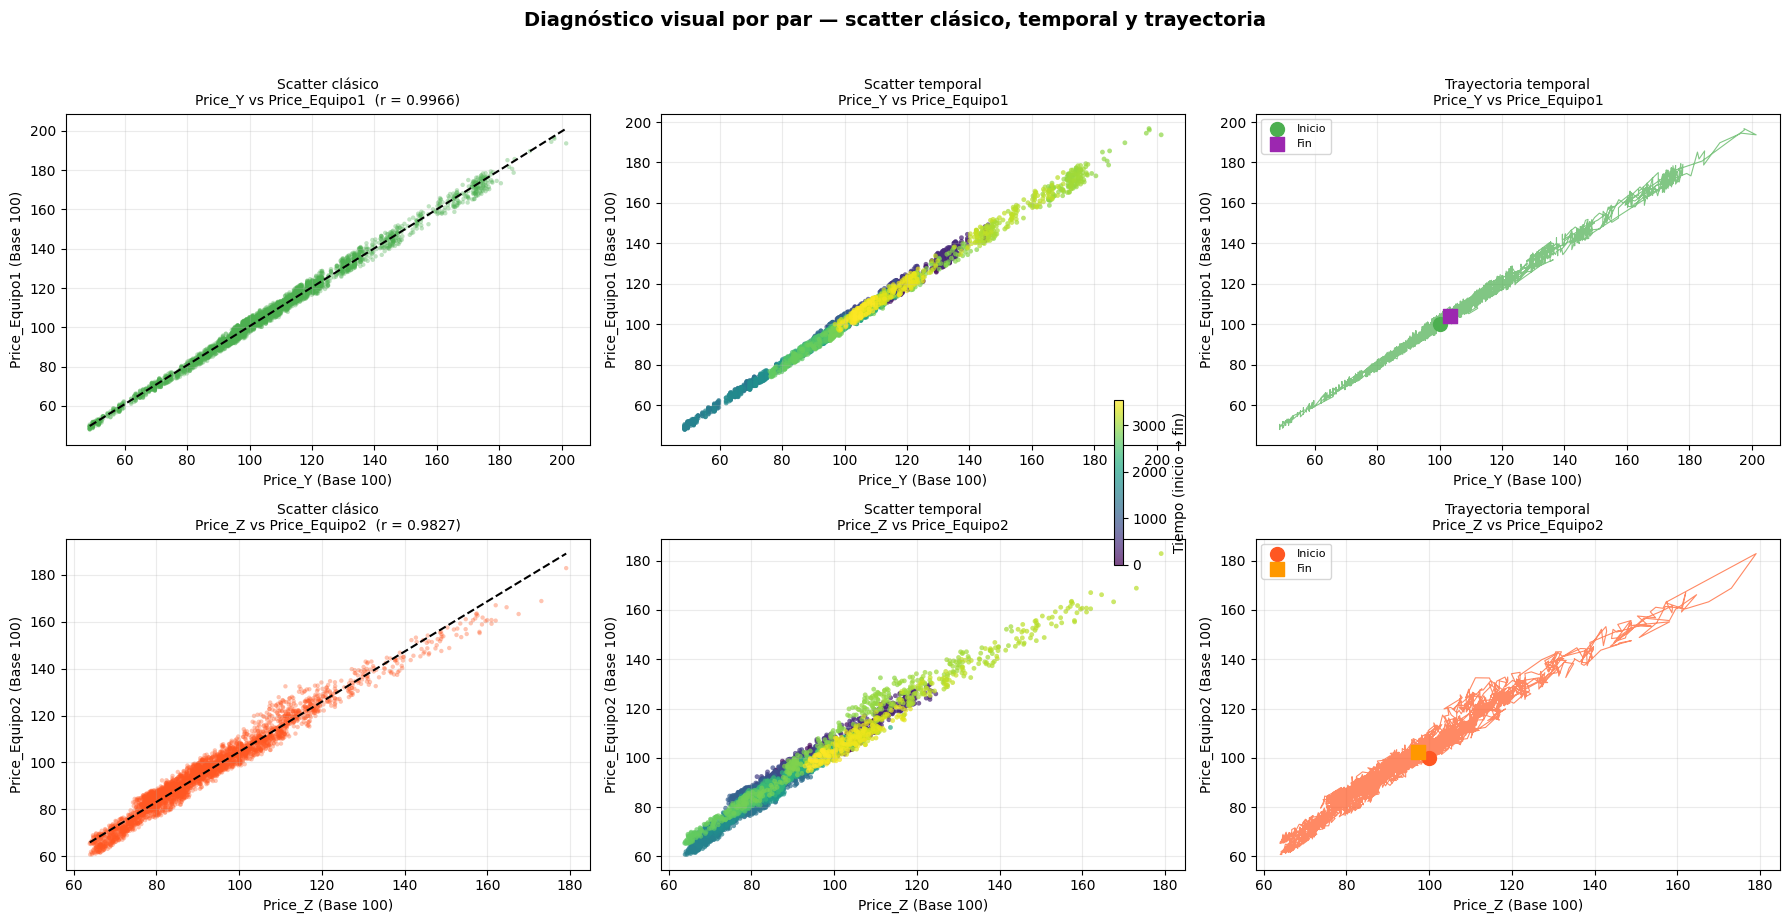

In [36]:
# =====================================================
# 1.4 PANEL — SCATTER CLÁSICO · TEMPORAL · TRAYECTORIA
# =====================================================

import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    'Diagnóstico visual por par — scatter clásico, temporal y trayectoria',
    fontsize=14, fontweight='bold', y=1.02,
)

fechas_num = mdates.date2num(df_plot.index.to_pydatetime())
stats_txt = 'r = {r:.4f}\nR² = {r2:.4f}'

for fila, (col_mp, col_eq, lbl_mp, lbl_eq, c_mp, c_eq) in enumerate(PARES):
    # Correlación en niveles originales (consistente con EDA)
    r_original = df_plot[col_mp].corr(df_plot[col_eq])
    r2_original = r_original ** 2

    # Plano scatter en Base 100
    x = series_base100[MAPA_BASE100[col_mp]].values
    y = series_base100[MAPA_BASE100[col_eq]].values

    # Col 0: Scatter clásico (Base 100)
    ax0 = axes[fila, 0]
    ax0.scatter(x, y, alpha=0.35, s=10, color=c_mp, edgecolors='none')
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax0.plot(x_line, np.poly1d(coef)(x_line), color='black', linewidth=1.5, linestyle='--')
    ax0.set_xlabel(f'{lbl_mp} (Base 100)')
    ax0.set_ylabel(f'{lbl_eq} (Base 100)')
    ax0.set_title(
        f'Scatter clásico\n{lbl_mp} vs {lbl_eq}\n'
        + stats_txt.format(r=r_original, r2=r2_original),
        fontsize=10,
    )
    ax0.grid(alpha=0.25)

    # Col 1: Scatter temporal (color = fecha real)
    ax1 = axes[fila, 1]
    sc = ax1.scatter(
        x, y,
        c=fechas_num, cmap='viridis',
        alpha=0.7, s=12, edgecolors='none',
    )
    ax1.set_xlabel(f'{lbl_mp} (Base 100)')
    ax1.set_ylabel(f'{lbl_eq} (Base 100)')
    ax1.set_title(
        f'Scatter temporal\n{lbl_mp} vs {lbl_eq}\n'
        + stats_txt.format(r=r_original, r2=r2_original),
        fontsize=10,
    )
    ax1.grid(alpha=0.25)
    if fila == 0:
        cbar = fig.colorbar(sc, ax=axes[:, 1].tolist(), fraction=0.02, pad=0.02)
        cbar.set_label('Fecha')
        cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        cbar.ax.yaxis.set_major_locator(mdates.YearLocator(2))

    # Col 2: Trayectoria temporal en el plano scatter
    ax2 = axes[fila, 2]
    ax2.plot(x, y, linewidth=0.8, alpha=0.7, color=c_mp)
    ax2.scatter(x[0], y[0], s=100, marker='o', color=c_mp, label='Inicio', zorder=3)
    ax2.scatter(x[-1], y[-1], s=100, marker='s', color=c_eq, label='Fin', zorder=3)
    ax2.set_xlabel(f'{lbl_mp} (Base 100)')
    ax2.set_ylabel(f'{lbl_eq} (Base 100)')
    ax2.set_title(
        f'Trayectoria temporal\n{lbl_mp} vs {lbl_eq}\n'
        + stats_txt.format(r=r_original, r2=r2_original),
        fontsize=10,
    )
    ax2.legend(loc='upper left', fontsize=8)
    ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'fig_diagnostico_panel_scatter_trayectoria.png', dpi=120, bbox_inches='tight')
plt.show()